In [124]:
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
import cv2
from collections import Counter

PROJECT_ROOT = Path.cwd().parent

MODEL_PATH = PROJECT_ROOT / "runs" / "baseline_dev" / "weights" / "best.pt"

model = YOLO(str(MODEL_PATH))

print("Model loaded:", MODEL_PATH)


Model loaded: d:\Data Science\Projects\AeroVision-Edge\runs\baseline_dev\weights\best.pt


In [125]:
VAL_IMAGES = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "visdrone_yolo"
    / "val"
    / "images"
)

VAL_LABELS = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "visdrone_yolo"
    / "val"
    / "labels"
)

print("Validation images:", len(list(VAL_IMAGES.glob("*.jpg"))))
print("Validation labels:", len(list(VAL_LABELS.glob("*.txt"))))

Validation images: 548
Validation labels: 548


In [126]:
CLASS_NAMES = [
    "pedestrian",
    "people",
    "bicycle",
    "car",
    "van",
    "truck",
    "tricycle",
    "awning-tricycle",
    "bus",
    "motor",
    "others"
]

In [127]:
sample_image = next(VAL_IMAGES.glob("*.jpg"))

print(sample_image)

d:\Data Science\Projects\AeroVision-Edge\data\processed\visdrone_yolo\val\images\0000001_02999_d_0000005.jpg


In [128]:
results = model.predict(
    source=str(sample_image),
    imgsz=640,
    device="cpu",
    verbose=False
)

print("Prediction completed.")

Prediction completed.


In [129]:
result = results[0]

print(type(result))

<class 'ultralytics.engine.results.Results'>


In [130]:
print(result.boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([3., 3., 3., 3., 3., 3., 3., 3., 9., 0., 0., 3., 0., 3., 0., 0., 9., 9., 0., 9., 3., 3., 3., 4., 3., 0.])
conf: tensor([0.8962, 0.7975, 0.7340, 0.7319, 0.6082, 0.5928, 0.4852, 0.4601, 0.4249, 0.3976, 0.3850, 0.3425, 0.3143, 0.3118, 0.3066, 0.3017, 0.3013, 0.2977, 0.2927, 0.2761, 0.2747, 0.2723, 0.2690, 0.2593, 0.2590, 0.2556])
data: tensor([[9.4785e+02, 5.9092e+02, 1.0118e+03, 6.8639e+02, 8.9619e-01, 3.0000e+00],
        [8.7153e+02, 5.6855e+02, 9.2632e+02, 6.6551e+02, 7.9750e-01, 3.0000e+00],
        [6.0874e+02, 3.6327e+02, 7.0834e+02, 4.1292e+02, 7.3404e-01, 3.0000e+00],
        [8.8273e+02, 7.0434e+02, 9.4157e+02, 8.1526e+02, 7.3190e-01, 3.0000e+00],
        [7.5197e+02, 3.2481e+02, 8.2464e+02, 3.7579e+02, 6.0823e-01, 3.0000e+00],
        [7.0683e+02, 3.4212e+02, 8.0059e+02, 4.0887e+02, 5.9281e-01, 3.0000e+00],
        [7.8466e+02, 1.8772e+02, 8.1224e+02, 2.2280e+02, 4.8515e-01, 3.0000e+00],
        [7.8267e+02, 

In [131]:
print("Boxes:", result.boxes.xyxy)
print("Confidence:", result.boxes.conf)
print("Classes:", result.boxes.cls)

Boxes: tensor([[ 947.8531,  590.9219, 1011.7934,  686.3907],
        [ 871.5313,  568.5486,  926.3238,  665.5134],
        [ 608.7364,  363.2729,  708.3419,  412.9248],
        [ 882.7326,  704.3394,  941.5737,  815.2570],
        [ 751.9741,  324.8122,  824.6441,  375.7946],
        [ 706.8256,  342.1197,  800.5866,  408.8659],
        [ 784.6624,  187.7220,  812.2449,  222.8003],
        [ 782.6743,  242.0463,  820.6793,  289.3741],
        [ 972.6866,  791.4875,  996.8789,  847.6393],
        [ 863.5117,  321.8325,  880.0322,  356.2797],
        [ 973.8104,  791.5745,  997.3867,  847.8135],
        [ 620.4702,  296.4965,  741.4905,  352.2334],
        [ 582.6436,  457.6848,  598.4237,  486.7648],
        [ 714.3484,  326.6178,  825.1635,  381.3130],
        [ 868.1376,  408.0459,  881.7508,  446.0641],
        [ 855.2371,   77.2177,  871.3542,  108.6980],
        [ 517.8593,  438.7235,  540.7866,  469.8779],
        [ 445.6013,  550.7702,  501.2669,  592.1876],
        [ 869.7360,  

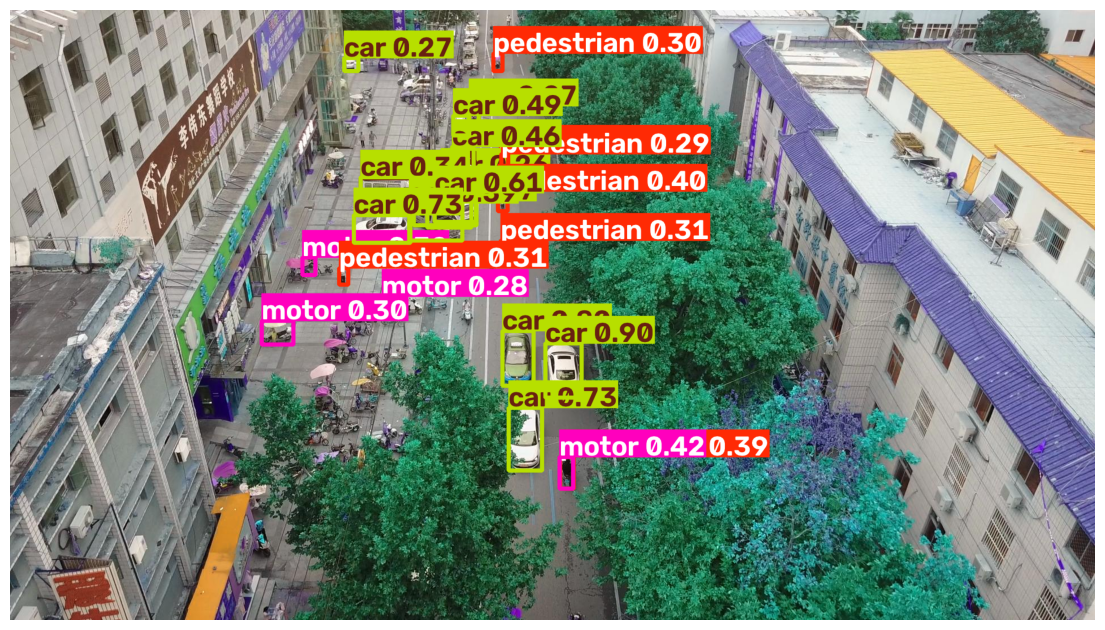

In [132]:
annotated = results[0].plot()

plt.figure(figsize=(14, 8))
plt.imshow(annotated)
plt.axis("off")
plt.show()

## Research Question

Does the baseline detector perform worse on smaller objects?

### Hypothesis

Objects occupying a smaller fraction of the image are expected
to be more difficult to detect because less visual information is
available to the detector.

In [133]:
def load_yolo_labels(label_path):
    """
    Read one YOLO label file.

    Returns:
        List of dictionaries containing:
        class_id and bounding box in normalized xywh format.
    """

    objects = []

    with open(label_path, "r") as file:
        for line in file:

            values = line.strip().split()

            if len(values) != 5:
                continue

            class_id = int(values[0])
            x_center = float(values[1])
            y_center = float(values[2])
            width = float(values[3])
            height = float(values[4])

            objects.append({
                "class_id": class_id,
                "x_center": x_center,
                "y_center": y_center,
                "width": width,
                "height": height
            })

    return objects

In [134]:
def yolo_to_xyxy(x_center, y_center, width, height):
    """
    Convert normalized YOLO xywh to normalized xyxy.
    """

    x1 = x_center - width / 2
    y1 = y_center - height / 2

    x2 = x_center + width / 2
    y2 = y_center + height / 2

    return [x1, y1, x2, y2]

In [135]:
def get_ground_truth_boxes(label_path):
    """
    Load YOLO labels and convert boxes to xyxy format.
    """

    labels = load_yolo_labels(label_path)

    ground_truths = []

    for label in labels:

        box = yolo_to_xyxy(
            label["x_center"],
            label["y_center"],
            label["width"],
            label["height"]
        )

        ground_truths.append({
            "class_id": label["class_id"],
            "box": box
        })

    return ground_truths

In [136]:
# Pick one validation image
sample_image = next(VAL_IMAGES.glob("*.jpg"))

# Corresponding YOLO label file
label_path = VAL_LABELS / f"{sample_image.stem}.txt"

print("Image:", sample_image.name)
print("Label:", label_path.name)

Image: 0000001_02999_d_0000005.jpg
Label: 0000001_02999_d_0000005.txt


In [137]:
ground_truths = get_ground_truth_boxes(label_path)

print(ground_truths[:3])

[{'class_id': 3, 'box': [0.45364550000000003, 0.5296295, 0.4817705, 0.6148145]}, {'class_id': 3, 'box': [0.49375, 0.5481484999999999, 0.526042, 0.6333335]}, {'class_id': 3, 'box': [0.455208, 0.652778, 0.49010400000000004, 0.75463]}]


In [138]:
result.boxes.xyxy
result.boxes.conf
result.boxes.cls

tensor([3., 3., 3., 3., 3., 3., 3., 3., 9., 0., 0., 3., 0., 3., 0., 0., 9., 9., 0., 9., 3., 3., 3., 4., 3., 0.])

In [139]:
def get_predictions(result):
    """
    Extract YOLO predictions into a simple Python structure.
    """

    predictions = []

    boxes = result.boxes

    for i in range(len(boxes)):

        x1, y1, x2, y2 = boxes.xyxy[i].tolist()

        confidence = float(boxes.conf[i])
        class_id = int(boxes.cls[i])

        predictions.append({
            "class_id": class_id,
            "box": [x1, y1, x2, y2],
            "confidence": confidence
        })

    return predictions

In [140]:
def calculate_iou(box1, box2):
    """
    Calculate Intersection over Union for two xyxy boxes.
    """

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])

    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_width = max(0, x2 - x1)
    intersection_height = max(0, y2 - y1)

    intersection_area = (
        intersection_width * intersection_height
    )

    area1 = max(0, box1[2] - box1[0]) * max(
        0, box1[3] - box1[1]
    )

    area2 = max(0, box2[2] - box2[0]) * max(
        0, box2[3] - box2[1]
    )

    union_area = area1 + area2 - intersection_area

    if union_area == 0:
        return 0.0

    return intersection_area / union_area

In [141]:
def match_predictions(
    predictions,
    ground_truths,
    iou_threshold=0.50
):
    """
    Match predictions to ground-truth objects.

    Returns:
        List of match results.
    """

    # Process highest-confidence predictions first
    predictions = sorted(
        predictions,
        key=lambda x: x["confidence"],
        reverse=True
    )

    matched_gt = set()
    matches = []

    for prediction in predictions:

        best_iou = 0.0
        best_gt_index = None

        for gt_index, ground_truth in enumerate(ground_truths):

            # Don't match the same GT twice
            if gt_index in matched_gt:
                continue

            # Classes must agree
            if prediction["class_id"] != ground_truth["class_id"]:
                continue

            iou = calculate_iou(
                prediction["box"],
                ground_truth["box"]
            )

            if iou > best_iou:
                best_iou = iou
                best_gt_index = gt_index

        # Did we find a valid match?
        if (
            best_gt_index is not None
            and best_iou >= iou_threshold
        ):

            matched_gt.add(best_gt_index)

            matches.append({
                "prediction": prediction,
                "gt_index": best_gt_index,
                "iou": best_iou,
                "status": "TP"
            })

        else:

            matches.append({
                "prediction": prediction,
                "gt_index": None,
                "iou": best_iou,
                "status": "FP"
            })

    # Every unmatched ground truth is an FN
    matched_gt_count = len(matched_gt)

    for gt_index in range(len(ground_truths)):

        if gt_index not in matched_gt:

            matches.append({
                "prediction": None,
                "gt_index": gt_index,
                "iou": 0.0,
                "status": "FN"
            })

    return matches

In [142]:
def match_predictions(
    predictions,
    ground_truths,
    iou_threshold=0.50
):
    """
    Match predictions to ground-truth objects.

    Returns:
        List of match results.
    """

    # Process highest-confidence predictions first
    predictions = sorted(
        predictions,
        key=lambda x: x["confidence"],
        reverse=True
    )

    matched_gt = set()
    matches = []

    for prediction in predictions:

        best_iou = 0.0
        best_gt_index = None

        for gt_index, ground_truth in enumerate(ground_truths):

            # Don't match the same GT twice
            if gt_index in matched_gt:
                continue

            # Classes must agree
            if prediction["class_id"] != ground_truth["class_id"]:
                continue

            iou = calculate_iou(
                prediction["box"],
                ground_truth["box"]
            )

            if iou > best_iou:
                best_iou = iou
                best_gt_index = gt_index

        # Did we find a valid match?
        if (
            best_gt_index is not None
            and best_iou >= iou_threshold
        ):

            matched_gt.add(best_gt_index)

            matches.append({
                "prediction": prediction,
                "gt_index": best_gt_index,
                "iou": best_iou,
                "status": "TP"
            })

        else:

            matches.append({
                "prediction": prediction,
                "gt_index": None,
                "iou": best_iou,
                "status": "FP"
            })

    # Every unmatched ground truth is an FN
    matched_gt_count = len(matched_gt)

    for gt_index in range(len(ground_truths)):

        if gt_index not in matched_gt:

            matches.append({
                "prediction": None,
                "gt_index": gt_index,
                "iou": 0.0,
                "status": "FN"
            })

    return matches

In [143]:
test_ground_truths = [
    {
        "class_id": 3,
        "box": [0.10, 0.10, 0.30, 0.30]
    },
    {
        "class_id": 0,
        "box": [0.50, 0.50, 0.70, 0.90]
    }
]

In [144]:
test_predictions = [
    {
        "class_id": 3,
        "box": [0.11, 0.11, 0.29, 0.29],
        "confidence": 0.95
    },
    {
        "class_id": 3,
        "box": [0.40, 0.40, 0.60, 0.60],
        "confidence": 0.80
    }
]

In [145]:
matches = match_predictions(
    test_predictions,
    test_ground_truths,
    iou_threshold=0.50
)

for match in matches:
    print(match)

{'prediction': {'class_id': 3, 'box': [0.11, 0.11, 0.29, 0.29], 'confidence': 0.95}, 'gt_index': 0, 'iou': 0.81, 'status': 'TP'}
{'prediction': {'class_id': 3, 'box': [0.4, 0.4, 0.6, 0.6], 'confidence': 0.8}, 'gt_index': None, 'iou': 0.0, 'status': 'FP'}
{'prediction': None, 'gt_index': 1, 'iou': 0.0, 'status': 'FN'}


In [146]:
# Run inference on the same validation image
results = model.predict(
    source=str(sample_image),
    imgsz=640,
    device="cpu",
    verbose=False
)

result = results[0]

# Convert predictions into our Python structure
predictions = get_predictions(result)

print("Number of predictions:", len(predictions))
print(predictions[:3])

Number of predictions: 26
[{'class_id': 3, 'box': [947.8531494140625, 590.921875, 1011.7933959960938, 686.3906860351562], 'confidence': 0.8961895108222961}, {'class_id': 3, 'box': [871.5313110351562, 568.548583984375, 926.3237915039062, 665.5133666992188], 'confidence': 0.7975012063980103}, {'class_id': 3, 'box': [608.7363891601562, 363.2729187011719, 708.3419189453125, 412.9248046875], 'confidence': 0.7340379953384399}]


In [147]:
matches = match_predictions(
    predictions,
    ground_truths,
    iou_threshold=0.50
)

for match in matches:
    print(match)

{'prediction': {'class_id': 3, 'box': [947.8531494140625, 590.921875, 1011.7933959960938, 686.3906860351562], 'confidence': 0.8961895108222961}, 'gt_index': None, 'iou': 0.0, 'status': 'FP'}
{'prediction': {'class_id': 3, 'box': [871.5313110351562, 568.548583984375, 926.3237915039062, 665.5133666992188], 'confidence': 0.7975012063980103}, 'gt_index': None, 'iou': 0.0, 'status': 'FP'}
{'prediction': {'class_id': 3, 'box': [608.7363891601562, 363.2729187011719, 708.3419189453125, 412.9248046875], 'confidence': 0.7340379953384399}, 'gt_index': None, 'iou': 0.0, 'status': 'FP'}
{'prediction': {'class_id': 3, 'box': [882.7326049804688, 704.3394165039062, 941.57373046875, 815.2570190429688], 'confidence': 0.7318962812423706}, 'gt_index': None, 'iou': 0.0, 'status': 'FP'}
{'prediction': {'class_id': 3, 'box': [751.97412109375, 324.8121643066406, 824.6441040039062, 375.7945861816406], 'confidence': 0.6082319021224976}, 'gt_index': None, 'iou': 0.0, 'status': 'FP'}
{'prediction': {'class_id': 3

In [148]:
# Count the results by status
status_counts = Counter(
    match["status"]
    for match in matches
)

print(status_counts)

Counter({'FN': 127, 'FP': 26})


In [149]:
print("TP:", status_counts["TP"])
print("FP:", status_counts["FP"])
print("FN:", status_counts["FN"])

TP: 0
FP: 26
FN: 127


In [150]:
for match in matches:
    if match["status"] == "TP":
        print(
            "GT index:",
            match["gt_index"],
            "IoU:",
            round(match["iou"], 3),
            "Class:",
            CLASS_NAMES[
                match["prediction"]["class_id"]
            ]
        )

In [151]:
for match in matches:
    if match["status"] == "FP":
        prediction = match["prediction"]

        print(
            "Predicted:",
            CLASS_NAMES[prediction["class_id"]],
            "Confidence:",
            round(prediction["confidence"], 3),
            "Best IoU:",
            round(match["iou"], 3)
        )

Predicted: car Confidence: 0.896 Best IoU: 0.0
Predicted: car Confidence: 0.798 Best IoU: 0.0
Predicted: car Confidence: 0.734 Best IoU: 0.0
Predicted: car Confidence: 0.732 Best IoU: 0.0
Predicted: car Confidence: 0.608 Best IoU: 0.0
Predicted: car Confidence: 0.593 Best IoU: 0.0
Predicted: car Confidence: 0.485 Best IoU: 0.0
Predicted: car Confidence: 0.46 Best IoU: 0.0
Predicted: motor Confidence: 0.425 Best IoU: 0.0
Predicted: pedestrian Confidence: 0.398 Best IoU: 0.0
Predicted: pedestrian Confidence: 0.385 Best IoU: 0.0
Predicted: car Confidence: 0.342 Best IoU: 0.0
Predicted: pedestrian Confidence: 0.314 Best IoU: 0.0
Predicted: car Confidence: 0.312 Best IoU: 0.0
Predicted: pedestrian Confidence: 0.307 Best IoU: 0.0
Predicted: pedestrian Confidence: 0.302 Best IoU: 0.0
Predicted: motor Confidence: 0.301 Best IoU: 0.0
Predicted: motor Confidence: 0.298 Best IoU: 0.0
Predicted: pedestrian Confidence: 0.293 Best IoU: 0.0
Predicted: motor Confidence: 0.276 Best IoU: 0.0
Predicted: 

In [152]:
for match in matches:
    if match["status"] == "FN":
        gt = ground_truths[match["gt_index"]]

        print(
            "Missed:",
            CLASS_NAMES[gt["class_id"]],
            "Box:",
            gt["box"]
        )

Missed: car Box: [0.45364550000000003, 0.5296295, 0.4817705, 0.6148145]
Missed: car Box: [0.49375, 0.5481484999999999, 0.526042, 0.6333335]
Missed: car Box: [0.455208, 0.652778, 0.49010400000000004, 0.75463]
Missed: motor Box: [0.5057285, 0.732407, 0.5197915, 0.7824070000000001]
Missed: people Box: [0.508333, 0.7351854999999999, 0.5182289999999999, 0.7703705]
Missed: motor Box: [0.21562499999999998, 0.8527775, 0.240625, 0.8953705000000001]
Missed: pedestrian Box: [0.2328125, 0.9759260000000001, 0.2468755, 1.0]
Missed: pedestrian Box: [0.2239585, 0.8351850000000001, 0.2380215, 0.880555]
Missed: awning-tricycle Box: [0.21093699999999999, 0.7749999999999999, 0.239583, 0.823148]
Missed: people Box: [0.216667, 0.7925924999999999, 0.22656300000000001, 0.8259255]
Missed: awning-tricycle Box: [0.181771, 0.7370375, 0.213021, 0.7935185]
Missed: motor Box: [0.19687449999999998, 0.6972225000000001, 0.2171875, 0.7379635]
Missed: motor Box: [0.32812450000000004, 0.6685185, 0.3572915, 0.7083335]
Miss

In [153]:
def load_visdrone_metadata(annotation_path):
    """
    Load the original VisDrone annotation information.

    Returns one dictionary per object.
    """

    objects = []

    with open(annotation_path, "r") as file:
        for line in file:

            values = line.strip().split(",")

            if len(values) != 8:
                continue

            x = int(values[0])
            y = int(values[1])
            width = int(values[2])
            height = int(values[3])

            score = int(values[4])
            category = int(values[5])
            truncation = int(values[6])
            occlusion = int(values[7])

            # Ignore regions
            if category == 0:
                continue

            # Ignore invalid/evaluation-excluded annotations
            if score == 0:
                continue

            # Invalid box
            if width <= 0 or height <= 0:
                continue

            if category not in CLASS_MAP:
                continue

            class_id = CLASS_MAP[category]

            objects.append({
                "class_id": class_id,
                "x": x,
                "y": y,
                "width": width,
                "height": height,
                "truncation": truncation,
                "occlusion": occlusion
            })

    return objects

In [154]:
RAW_VAL_ANNOTATIONS = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "visdrone"
    / "VisDrone2019-DET-val"
    / "annotations"
)

raw_annotation_path = (
    RAW_VAL_ANNOTATIONS
    / f"{sample_image.stem}.txt"
)

print(raw_annotation_path)

d:\Data Science\Projects\AeroVision-Edge\data\raw\visdrone\VisDrone2019-DET-val\annotations\0000001_02999_d_0000005.txt


In [155]:
CLASS_MAP = {
    1: 0,   # pedestrian
    2: 1,   # people
    3: 2,   # bicycle
    4: 3,   # car
    5: 4,   # van
    6: 5,   # truck
    7: 6,   # tricycle
    8: 7,   # awning-tricycle
    9: 8,   # bus
    10: 9,  # motor
    11: 10  # others
}

In [156]:
visdrone_objects = load_visdrone_metadata(
    raw_annotation_path
)

print(visdrone_objects[:3])

[{'class_id': 3, 'x': 871, 'y': 572, 'width': 54, 'height': 92, 'truncation': 0, 'occlusion': 0}, {'class_id': 3, 'x': 948, 'y': 592, 'width': 62, 'height': 92, 'truncation': 0, 'occlusion': 0}, {'class_id': 3, 'x': 874, 'y': 705, 'width': 67, 'height': 110, 'truncation': 0, 'occlusion': 1}]


In [157]:
def visdrone_to_normalized_xyxy(
    x,
    y,
    width,
    height,
    image_width,
    image_height
):
    x1 = x / image_width
    y1 = y / image_height

    x2 = (x + width) / image_width
    y2 = (y + height) / image_height

    return [x1, y1, x2, y2]

In [158]:
def normalize_prediction_boxes(
    predictions,
    image_width,
    image_height
):
    normalized_predictions = []

    for prediction in predictions:

        x1, y1, x2, y2 = prediction["box"]

        normalized_box = [
            x1 / image_width,
            y1 / image_height,
            x2 / image_width,
            y2 / image_height
        ]

        normalized_predictions.append({
            "class_id": prediction["class_id"],
            "box": normalized_box,
            "confidence": prediction["confidence"]
        })

    return normalized_predictions

In [159]:
image = cv2.imread(str(sample_image))
image_height, image_width = image.shape[:2]

predictions_normalized = normalize_prediction_boxes(
    predictions,
    image_width,
    image_height
)

In [160]:
def calculate_relative_area(
    width,
    height,
    image_width,
    image_height
):
    return (
        width * height
    ) / (
        image_width * image_height
    )

In [161]:
{
    "class": "pedestrian",
    "relative_area": 0.00031,
    "occlusion": 1,
    "truncation": 0,
    "detected": True,
    "iou": 0.63
}

{'class': 'pedestrian',
 'relative_area': 0.00031,
 'occlusion': 1,
 'truncation': 0,
 'detected': True,
 'iou': 0.63}

In [162]:
print("Ground-truth objects:", len(ground_truths))
print("Predictions:", len(predictions))
print("VisDrone metadata objects:", len(visdrone_objects))

Ground-truth objects: 127
Predictions: 26
VisDrone metadata objects: 127


In [163]:
for obj in visdrone_objects[:5]:
    print(obj)

{'class_id': 3, 'x': 871, 'y': 572, 'width': 54, 'height': 92, 'truncation': 0, 'occlusion': 0}
{'class_id': 3, 'x': 948, 'y': 592, 'width': 62, 'height': 92, 'truncation': 0, 'occlusion': 0}
{'class_id': 3, 'x': 874, 'y': 705, 'width': 67, 'height': 110, 'truncation': 0, 'occlusion': 1}
{'class_id': 9, 'x': 971, 'y': 791, 'width': 27, 'height': 54, 'truncation': 0, 'occlusion': 1}
{'class_id': 1, 'x': 976, 'y': 794, 'width': 19, 'height': 38, 'truncation': 0, 'occlusion': 1}


In [164]:
image = cv2.imread(str(sample_image))
image_height, image_width = image.shape[:2]

ground_truths_with_metadata = []

for obj in visdrone_objects:

    box = visdrone_to_normalized_xyxy(
        obj["x"],
        obj["y"],
        obj["width"],
        obj["height"],
        image_width,
        image_height
    )

    relative_area = calculate_relative_area(
        obj["width"],
        obj["height"],
        image_width,
        image_height
    )

    ground_truths_with_metadata.append({
        "class_id": obj["class_id"],
        "box": box,
        "relative_area": relative_area,
        "occlusion": obj["occlusion"],
        "truncation": obj["truncation"]
    })

print(
    "Ground truths with metadata:",
    len(ground_truths_with_metadata)
)

print(ground_truths_with_metadata[:3])

Ground truths with metadata: 127
[{'class_id': 3, 'box': [0.45364583333333336, 0.5296296296296297, 0.4817708333333333, 0.6148148148148148], 'relative_area': 0.002395833333333333, 'occlusion': 0, 'truncation': 0}, {'class_id': 3, 'box': [0.49375, 0.5481481481481482, 0.5260416666666666, 0.6333333333333333], 'relative_area': 0.0027507716049382717, 'occlusion': 0, 'truncation': 0}, {'class_id': 3, 'box': [0.4552083333333333, 0.6527777777777778, 0.4901041666666667, 0.7546296296296297], 'relative_area': 0.0035542052469135802, 'occlusion': 1, 'truncation': 0}]


In [165]:
predictions_normalized = normalize_prediction_boxes(
    predictions,
    image_width,
    image_height
)

print(predictions_normalized[:3])

[{'class_id': 3, 'box': [0.49367351531982423, 0.5471498842592593, 0.5269757270812988, 0.6355469315140335], 'confidence': 0.8961895108222961}, {'class_id': 3, 'box': [0.45392255783081054, 0.5264338740596065, 0.48246030807495116, 0.6162160802770544], 'confidence': 0.7975012063980103}, {'class_id': 3, 'box': [0.3170502026875814, 0.3363638136121962, 0.36892808278401695, 0.3823377821180556], 'confidence': 0.7340379953384399}]


In [166]:
matches = match_predictions(
    predictions_normalized,
    ground_truths_with_metadata,
    iou_threshold=0.50
)

In [167]:
status_counts = Counter(
    match["status"]
    for match in matches
)

print(status_counts)

Counter({'FN': 117, 'FP': 16, 'TP': 10})


In [168]:
object_records = []

for match in matches:

    # We are interested in ground-truth objects.
    # Therefore every row must correspond to a GT object.
    if match["gt_index"] is None:
        # This is an FP with no matched GT.
        continue

    gt = ground_truths_with_metadata[match["gt_index"]]

    record = {
        "class_id": gt["class_id"],
        "class_name": CLASS_NAMES[gt["class_id"]],
        "relative_area": gt["relative_area"],
        "occlusion": gt["occlusion"],
        "truncation": gt["truncation"],
        "status": match["status"],
        "iou": match["iou"]
    }

    if match["prediction"] is not None:
        record["confidence"] = match["prediction"]["confidence"]
    else:
        record["confidence"] = 0.0

    object_records.append(record)


object_df = pd.DataFrame(object_records)

object_df.head()

,class_id,class_name,relative_area,occlusion,truncation,status,iou,confidence
0,3,car,0.002751,0,0,TP,0.934423,0.896190
1,3,car,0.002396,0,0,TP,0.917434,0.797501
2,3,car,0.002316,1,0,TP,0.909238,0.734038
3,3,car,0.003554,1,0,TP,0.856061,0.731896
4,3,car,0.001856,1,0,TP,0.962137,0.608232


In [169]:
object_df["detected"] = (
    object_df["status"] == "TP"
).astype(int)

object_df.head()

,class_id,class_name,relative_area,occlusion,truncation,status,iou,confidence,detected
0,3,car,0.002751,0,0,TP,0.934423,0.896190,1
1,3,car,0.002396,0,0,TP,0.917434,0.797501,1
2,3,car,0.002316,1,0,TP,0.909238,0.734038,1
3,3,car,0.003554,1,0,TP,0.856061,0.731896,1
4,3,car,0.001856,1,0,TP,0.962137,0.608232,1


In [170]:
print("Ground-truth objects analyzed:", len(object_df))

print(
    "Detected:",
    object_df["detected"].sum()
)

print(
    "Missed:",
    (object_df["detected"] == 0).sum()
)

Ground-truth objects analyzed: 127
Detected: 10
Missed: 117


In [171]:
print(
    object_df["status"].value_counts()
)

status
FN    117
TP     10
Name: count, dtype: int64


In [172]:
print(
    object_df["status"].value_counts()
)

status
FN    117
TP     10
Name: count, dtype: int64


In [173]:
object_df["size_group"] = pd.qcut(
    object_df["relative_area"],
    q=[0, 0.10, 0.50, 0.90, 1.00],
    labels=[
        "smallest_10%",
        "10-50%",
        "50-90%",
        "largest_10%"
    ],
    duplicates="drop"
)

In [174]:
size_analysis = (
    object_df
    .groupby("size_group", observed=True)
    .agg(
        objects=("detected", "count"),
        detected=("detected", "sum"),
        detection_rate=("detected", "mean")
    )
    .reset_index()
)

size_analysis

,size_group,objects,detected,detection_rate
0,smallest_10%,13,0,0.000000
1,10-50%,51,1,0.019608
2,50-90%,50,3,0.060000
3,largest_10%,13,6,0.461538


In [175]:
occlusion_analysis = (
    object_df
    .groupby("occlusion")
    .agg(
        objects=("detected", "count"),
        detected=("detected", "sum"),
        detection_rate=("detected", "mean")
    )
    .reset_index()
)

occlusion_analysis

,occlusion,objects,detected,detection_rate
0,0,9,3,0.333333
1,1,107,7,0.065421
2,2,11,0,0.000000


In [176]:
occlusion_analysis["occlusion_name"] = (
    occlusion_analysis["occlusion"]
    .map({
        0: "none",
        1: "partial",
        2: "heavy"
    })
)

occlusion_analysis

,occlusion,objects,detected,detection_rate,occlusion_name
0,0,9,3,0.333333,none
1,1,107,7,0.065421,partial
2,2,11,0,0.000000,heavy


In [177]:
truncation_analysis = (
    object_df
    .groupby("truncation")
    .agg(
        objects=("detected", "count"),
        detected=("detected", "sum"),
        detection_rate=("detected", "mean")
    )
    .reset_index()
)

truncation_analysis

,truncation,objects,detected,detection_rate
0,0,126,10,0.079365
1,1,1,0,0.000000


In [178]:
def analyze_one_image(image_path, imgsz=640):
    """
    Run inference and object-level error analysis
    for one validation image.
    """

    # ---------------------------------------------
    # Image dimensions
    # ---------------------------------------------
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image_height, image_width = image.shape[:2]


    # ---------------------------------------------
    # Original VisDrone annotation
    # ---------------------------------------------
    raw_annotation_path = (
        RAW_VAL_ANNOTATIONS
        / f"{image_path.stem}.txt"
    )

    visdrone_objects = load_visdrone_metadata(
        raw_annotation_path
    )


    # ---------------------------------------------
    # Ground-truth boxes + metadata
    # ---------------------------------------------
    ground_truths = []

    for obj in visdrone_objects:

        box = visdrone_to_normalized_xyxy(
            obj["x"],
            obj["y"],
            obj["width"],
            obj["height"],
            image_width,
            image_height
        )

        relative_area = calculate_relative_area(
            obj["width"],
            obj["height"],
            image_width,
            image_height
        )

        ground_truths.append({
            "class_id": obj["class_id"],
            "box": box,
            "relative_area": relative_area,
            "occlusion": obj["occlusion"],
            "truncation": obj["truncation"]
        })


    # ---------------------------------------------
    # Model prediction
    # ---------------------------------------------
    results = model.predict(
        source=str(image_path),
        imgsz=imgsz,
        device="cpu",
        verbose=False
    )

    result = results[0]

    predictions = get_predictions(result)

    predictions = normalize_prediction_boxes(
        predictions,
        image_width,
        image_height
    )


    # ---------------------------------------------
    # Match predictions to ground truth
    # ---------------------------------------------
    matches = match_predictions(
        predictions,
        ground_truths,
        iou_threshold=0.50
    )


    # ---------------------------------------------
    # Convert matches into GT-level records
    # ---------------------------------------------
    records = []

    for match in matches:

        # Ignore predictions that have no GT.
        if match["gt_index"] is None:
            continue

        gt = ground_truths[match["gt_index"]]

        records.append({
            "image": image_path.name,
            "class_id": gt["class_id"],
            "class_name": CLASS_NAMES[gt["class_id"]],
            "relative_area": gt["relative_area"],
            "occlusion": gt["occlusion"],
            "truncation": gt["truncation"],
            "detected": int(match["status"] == "TP"),
            "status": match["status"],
            "iou": match["iou"]
        })

    return records

In [179]:
test_records = []

for image_path in list(VAL_IMAGES.glob("*.jpg"))[:5]:

    records = analyze_one_image(image_path)

    test_records.extend(records)

print("Objects analyzed:", len(test_records))

Objects analyzed: 480


In [180]:
test_df = pd.DataFrame(test_records)

test_df.head()

,image,class_id,class_name,relative_area,occlusion,truncation,detected,status,iou
0,0000001_02999_d_0000005.jpg,3,car,0.002751,0,0,1,TP,0.934423
1,0000001_02999_d_0000005.jpg,3,car,0.002396,0,0,1,TP,0.917434
2,0000001_02999_d_0000005.jpg,3,car,0.002316,1,0,1,TP,0.909238
3,0000001_02999_d_0000005.jpg,3,car,0.003554,1,0,1,TP,0.856061
4,0000001_02999_d_0000005.jpg,3,car,0.001856,1,0,1,TP,0.962137


In [181]:
print(test_df["status"].value_counts())

status
FN    403
TP     77
Name: count, dtype: int64


In [182]:
all_records = []

image_paths = sorted(VAL_IMAGES.glob("*.jpg"))

for index, image_path in enumerate(image_paths):

    records = analyze_one_image(image_path)

    all_records.extend(records)

    if (index + 1) % 25 == 0:
        print(
            f"Processed {index + 1}/{len(image_paths)} images"
        )

object_df = pd.DataFrame(all_records)

print(
    "Total objects analyzed:",
    len(object_df)
)

Processed 25/548 images
Processed 50/548 images
Processed 75/548 images
Processed 100/548 images
Processed 125/548 images
Processed 150/548 images
Processed 175/548 images
Processed 200/548 images
Processed 225/548 images
Processed 250/548 images
Processed 275/548 images
Processed 300/548 images
Processed 325/548 images
Processed 350/548 images
Processed 375/548 images
Processed 400/548 images
Processed 425/548 images
Processed 450/548 images
Processed 475/548 images
Processed 500/548 images
Processed 525/548 images
Total objects analyzed: 38759


In [183]:
output_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "baseline_object_analysis.csv"
)

object_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: d:\Data Science\Projects\AeroVision-Edge\data\processed\baseline_object_analysis.csv


In [184]:
# Basic Integrity Check
print("Rows:", len(object_df))

print("\nColumns:")
print(object_df.columns.tolist())

print("\nMissing values:")
print(object_df.isna().sum())

Rows: 38759

Columns:
['image', 'class_id', 'class_name', 'relative_area', 'occlusion', 'truncation', 'detected', 'status', 'iou']

Missing values:
image            0
class_id         0
class_name       0
relative_area    0
occlusion        0
truncation       0
detected         0
status           0
iou              0
dtype: int64


In [185]:
# Detection Outcomes Check
print(object_df["status"].value_counts())

status
FN    28606
TP    10153
Name: count, dtype: int64


In [186]:
# Class check
print(object_df["class_name"].value_counts())

class_name
car                14064
pedestrian          8844
people              5125
motor               4886
van                 1975
bicycle             1287
tricycle            1045
truck                750
awning-tricycle      532
bus                  251
Name: count, dtype: int64


In [187]:
# Object Sizes Check
print(object_df["relative_area"].describe())

print(
    "Minimum relative area:",
    object_df["relative_area"].min()
)

print(
    "Maximum relative area:",
    object_df["relative_area"].max()
)

count    38759.000000
mean         0.001536
std          0.004314
min          0.000006
25%          0.000222
50%          0.000552
75%          0.001384
max          0.341630
Name: relative_area, dtype: float64
Minimum relative area: 5.7670126874279126e-06
Maximum relative area: 0.3416301422529796


In [188]:
print(object_df["occlusion"].value_counts().sort_index())

occlusion
0    16810
1    18863
2     3086
Name: count, dtype: int64


In [189]:
size_boundaries = object_df["relative_area"].quantile(
    [0.10, 0.50, 0.90]
)

print(size_boundaries)

0.1    0.000101
0.5    0.000552
0.9    0.003499
Name: relative_area, dtype: float64


In [190]:
def assign_size_group(area):
    if area <= size_boundaries.loc[0.10]:
        return "smallest_10%"

    elif area <= size_boundaries.loc[0.50]:
        return "10-50%"

    elif area <= size_boundaries.loc[0.90]:
        return "50-90%"

    else:
        return "largest_10%"

In [191]:
object_df["size_group"] = (
    object_df["relative_area"]
    .apply(assign_size_group)
)

In [192]:
print(
    object_df["size_group"].value_counts()
)

size_group
50-90%          15498
10-50%          15461
smallest_10%     3924
largest_10%      3876
Name: count, dtype: int64


In [193]:
size_analysis = (
    object_df
    .groupby("size_group", observed=True)
    .agg(
        objects=("detected", "count"),
        detected=("detected", "sum"),
        detection_rate=("detected", "mean")
    )
    .reset_index()
)

size_analysis

,size_group,objects,detected,detection_rate
0,10-50%,15461,1528,0.098829
1,50-90%,15498,5836,0.376565
2,largest_10%,3876,2780,0.717234
3,smallest_10%,3924,9,0.002294


In [194]:
occlusion_analysis = (
    object_df
    .groupby("occlusion")
    .agg(
        objects=("detected", "count"),
        detected=("detected", "sum"),
        detection_rate=("detected", "mean")
    )
    .reset_index()
)

occlusion_analysis["occlusion_name"] = (
    occlusion_analysis["occlusion"]
    .map({
        0: "none",
        1: "partial",
        2: "heavy"
    })
)

occlusion_analysis

,occlusion,objects,detected,detection_rate,occlusion_name
0,0,16810,6633,0.394587,none
1,1,18863,3360,0.178126,partial
2,2,3086,160,0.051847,heavy


In [195]:
class_analysis = (
    object_df
    .groupby(["class_id", "class_name"])
    .agg(
        objects=("detected", "count"),
        detected=("detected", "sum"),
        detection_rate=("detected", "mean")
    )
    .reset_index()
)

class_analysis

,class_id,class_name,objects,detected,detection_rate
0,0,pedestrian,8844,1726,0.195161
1,1,people,5125,0,0.000000
2,2,bicycle,1287,1,0.000777
3,3,car,14064,7849,0.558092
4,4,van,1975,144,0.072911
5,5,truck,750,69,0.092000
6,6,tricycle,1045,0,0.000000
7,7,awning-tricycle,532,0,0.000000
8,8,bus,251,42,0.167331
9,9,motor,4886,322,0.065903


In [196]:
size_group_order = [
    "smallest_10%",
    "10-50%",
    "50-90%",
    "largest_10%"
]

object_df["size_group"] = pd.Categorical(
    object_df["size_group"],
    categories=size_group_order,
    ordered=True
)

In [197]:
size_occlusion_analysis = (
    object_df
    .groupby(
        ["size_group", "occlusion"],
        observed=True
    )
    .agg(
        objects=("detected", "count"),
        detected=("detected", "sum"),
        detection_rate=("detected", "mean")
    )
    .reset_index()
)

size_occlusion_analysis["occlusion_name"] = (
    size_occlusion_analysis["occlusion"]
    .map({
        0: "none",
        1: "partial",
        2: "heavy"
    })
)

size_occlusion_analysis

,size_group,occlusion,objects,detected,detection_rate,occlusion_name
0,smallest_10%,0,1726,9,0.005214,none
1,smallest_10%,1,1945,0,0.000000,partial
2,smallest_10%,2,253,0,0.000000,heavy
3,10-50%,0,6252,1105,0.176743,none
4,10-50%,1,7891,396,0.050184,partial
5,10-50%,2,1318,27,0.020486,heavy
6,50-90%,0,6575,3648,0.554829,none
7,50-90%,1,7615,2097,0.275378,partial
8,50-90%,2,1308,91,0.069572,heavy
9,largest_10%,0,2257,1871,0.828977,none


In [198]:
size_occlusion_pivot = size_occlusion_analysis.pivot(
    index="size_group",
    columns="occlusion_name",
    values="detection_rate"
)

size_occlusion_pivot

occlusion_name,heavy,none,partial
size_group,,,
smallest_10%,0.000000,0.005214,0.000000
10-50%,0.020486,0.176743,0.050184
50-90%,0.069572,0.554829,0.275378
largest_10%,0.202899,0.828977,0.614023


In [199]:
count_pivot = size_occlusion_analysis.pivot(
    index="size_group",
    columns="occlusion_name",
    values="objects"
)

count_pivot

occlusion_name,heavy,none,partial
size_group,,,
smallest_10%,253,1726,1945
10-50%,1318,6252,7891
50-90%,1308,6575,7615
largest_10%,207,2257,1412


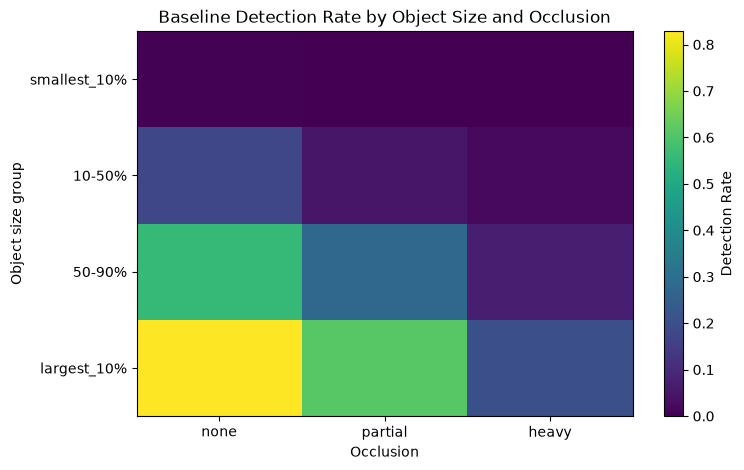

In [200]:
plot_data = size_occlusion_pivot[
    ["none", "partial", "heavy"]
]

plt.figure(figsize=(8, 5))

plt.imshow(
    plot_data.values,
    aspect="auto"
)

plt.xticks(
    range(len(plot_data.columns)),
    plot_data.columns
)

plt.yticks(
    range(len(plot_data.index)),
    plot_data.index
)

plt.xlabel("Occlusion")
plt.ylabel("Object size group")
plt.title("Baseline Detection Rate by Object Size and Occlusion")

plt.colorbar(label="Detection Rate")

plt.show()

In [201]:
size_occlusion_output = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "baseline_size_occlusion_analysis.csv"
)

size_occlusion_analysis.to_csv(
    size_occlusion_output,
    index=False
)

print("Saved:", size_occlusion_output)

Saved: d:\Data Science\Projects\AeroVision-Edge\data\processed\baseline_size_occlusion_analysis.csv


In [202]:
image_crowding = (
    object_df
    .groupby("image")
    .size()
    .reset_index(name="object_count")
)

image_crowding.head()

,image,object_count
0,0000001_02999_d_0000005.jpg,127
1,0000001_03499_d_0000006.jpg,77
2,0000001_03999_d_0000007.jpg,48
3,0000001_04527_d_0000008.jpg,115
4,0000001_05249_d_0000009.jpg,113


In [203]:
print(
    image_crowding["object_count"].describe()
)

count    548.000000
mean      70.728102
std       45.995439
min        1.000000
25%       39.750000
50%       65.000000
75%       93.000000
max      317.000000
Name: object_count, dtype: float64


In [204]:
print(
    image_crowding["object_count"].describe()
)

count    548.000000
mean      70.728102
std       45.995439
min        1.000000
25%       39.750000
50%       65.000000
75%       93.000000
max      317.000000
Name: object_count, dtype: float64


In [205]:
crowding_boundaries = image_crowding[
    "object_count"
].quantile(
    [0.25, 0.50, 0.75]
)

print(crowding_boundaries)

0.25    39.75
0.50    65.00
0.75    93.00
Name: object_count, dtype: float64


In [206]:
def assign_crowding_group(count):

    if count <= crowding_boundaries.loc[0.25]:
        return "lowest_25%"

    elif count <= crowding_boundaries.loc[0.50]:
        return "25-50%"

    elif count <= crowding_boundaries.loc[0.75]:
        return "50-75%"

    else:
        return "highest_25%"

In [207]:
image_crowding["crowding_group"] = (
    image_crowding["object_count"]
    .apply(assign_crowding_group)
)

In [208]:
print(
    image_crowding["crowding_group"].value_counts()
)

crowding_group
50-75%         140
25-50%         140
lowest_25%     137
highest_25%    131
Name: count, dtype: int64


In [209]:
object_df = object_df.merge(
    image_crowding[
        [
            "image",
            "object_count",
            "crowding_group"
        ]
    ],
    on="image",
    how="left"
)

In [210]:
print(
    object_df[
        ["image", "object_count", "crowding_group"]
    ].head()
)

                         image  object_count crowding_group
0  0000001_02999_d_0000005.jpg           127    highest_25%
1  0000001_02999_d_0000005.jpg           127    highest_25%
2  0000001_02999_d_0000005.jpg           127    highest_25%
3  0000001_02999_d_0000005.jpg           127    highest_25%
4  0000001_02999_d_0000005.jpg           127    highest_25%


In [211]:
print(
    "Missing crowding groups:",
    object_df["crowding_group"].isna().sum()
)

Missing crowding groups: 0


In [212]:
crowding_analysis = (
    object_df
    .groupby(
        "crowding_group",
        observed=True
    )
    .agg(
        objects=("detected", "count"),
        detected=("detected", "sum"),
        detection_rate=("detected", "mean"),
        mean_object_count=("object_count", "mean")
    )
    .reset_index()
)

crowding_analysis

,crowding_group,objects,detected,detection_rate,mean_object_count
0,25-50%,7426,2194,0.295448,54.117425
1,50-75%,11170,3067,0.274575,80.537869
2,highest_25%,17278,3822,0.221206,145.793726
3,lowest_25%,2885,1070,0.370884,27.058925


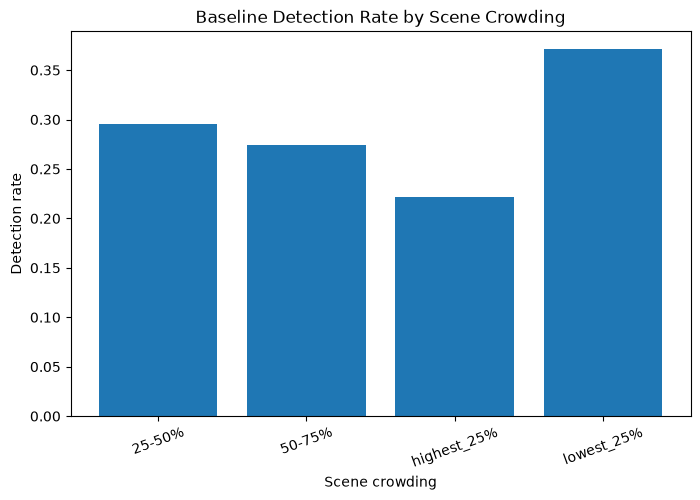

In [213]:
plt.figure(figsize=(8, 5))

plt.bar(
    crowding_analysis["crowding_group"],
    crowding_analysis["detection_rate"]
)

plt.xlabel("Scene crowding")
plt.ylabel("Detection rate")
plt.title("Baseline Detection Rate by Scene Crowding")

plt.xticks(rotation=20)

plt.show()

In [214]:
crowding_size_analysis = (
    object_df
    .groupby(
        "crowding_group",
        observed=True
    )
    .agg(
        objects=("relative_area", "count"),
        median_object_area=("relative_area", "median"),
        mean_object_area=("relative_area", "mean"),
        median_width=("relative_area", "median")
    )
    .reset_index()
)

crowding_size_analysis

,crowding_group,objects,median_object_area,mean_object_area,median_width
0,25-50%,7426,0.000648,0.001735,0.000648
1,50-75%,11170,0.000554,0.001431,0.000554
2,highest_25%,17278,0.000467,0.001122,0.000467
3,lowest_25%,2885,0.001130,0.003911,0.001130


In [215]:
size_order = [
    "smallest_10%",
    "10-50%",
    "50-90%",
    "largest_10%"
]

crowding_order = [
    "lowest_25%",
    "25-50%",
    "50-75%",
    "highest_25%"
]

object_df["size_group"] = pd.Categorical(
    object_df["size_group"],
    categories=size_order,
    ordered=True
)

object_df["crowding_group"] = pd.Categorical(
    object_df["crowding_group"],
    categories=crowding_order,
    ordered=True
)

In [216]:
crowding_size_analysis = (
    object_df
    .groupby(
        ["crowding_group", "size_group"],
        observed=True
    )
    .agg(
        objects=("detected", "count"),
        detected=("detected", "sum"),
        detection_rate=("detected", "mean")
    )
    .reset_index()
)

crowding_size_analysis

,crowding_group,size_group,objects,detected,detection_rate
0,lowest_25%,smallest_10%,208,0,0.000000
1,lowest_25%,10-50%,704,84,0.119318
2,lowest_25%,50-90%,1268,493,0.388801
3,lowest_25%,largest_10%,705,493,0.699291
4,25-50%,smallest_10%,691,2,0.002894
5,25-50%,10-50%,2688,293,0.109003
6,25-50%,50-90%,3132,1270,0.405492
7,25-50%,largest_10%,915,629,0.687432
8,50-75%,smallest_10%,1080,2,0.001852
9,50-75%,10-50%,4478,473,0.105628


In [217]:
crowding_size_pivot = crowding_size_analysis.pivot(
    index="crowding_group",
    columns="size_group",
    values="detection_rate"
)

crowding_size_pivot

size_group,smallest_10%,10-50%,50-90%,largest_10%
crowding_group,,,,
lowest_25%,0.000000,0.119318,0.388801,0.699291
25-50%,0.002894,0.109003,0.405492,0.687432
50-75%,0.001852,0.105628,0.396556,0.734995
highest_25%,0.002571,0.089316,0.346628,0.734868


In [218]:
crowding_size_counts = crowding_size_analysis.pivot(
    index="crowding_group",
    columns="size_group",
    values="objects"
)

crowding_size_counts

size_group,smallest_10%,10-50%,50-90%,largest_10%
crowding_group,,,,
lowest_25%,208,704,1268,705
25-50%,691,2688,3132,915
50-75%,1080,4478,4529,1083
highest_25%,1945,7591,6569,1173


## Preliminary Baseline Findings

1. Detection performance strongly decreases as object size decreases.

2. Detection performance decreases substantially with increasing occlusion.

3. Overall detection rate is lower in more crowded scenes.

4. After controlling for object size, the crowding effect becomes much
less consistent, suggesting that part of the observed crowding effect may
be associated with smaller objects in crowded scenes.

5. These findings motivate further class-specific and controlled error
analysis before selecting model improvements.

In [219]:
class_size_analysis = (
    object_df
    .groupby(
        ["class_name", "size_group"],
        observed=True
    )
    .agg(
        objects=("detected", "count"),
        detected=("detected", "sum"),
        detection_rate=("detected", "mean")
    )
    .reset_index()
)

class_size_analysis

,class_name,size_group,objects,detected,detection_rate
0,awning-tricycle,smallest_10%,18,0,0.000000
1,awning-tricycle,10-50%,145,0,0.000000
2,awning-tricycle,50-90%,303,0,0.000000
3,awning-tricycle,largest_10%,66,0,0.000000
4,bicycle,smallest_10%,120,0,0.000000
5,bicycle,10-50%,647,0,0.000000
6,bicycle,50-90%,503,1,0.001988
7,bicycle,largest_10%,17,0,0.000000
8,bus,smallest_10%,12,0,0.000000
9,bus,10-50%,56,0,0.000000


In [220]:
class_size_pivot = class_size_analysis.pivot(
    index="class_name",
    columns="size_group",
    values="detection_rate"
)

class_size_pivot

size_group,smallest_10%,10-50%,50-90%,largest_10%
class_name,,,,
awning-tricycle,0.000000,0.000000,0.000000,0.000000
bicycle,0.000000,0.000000,0.001988,0.000000
bus,0.000000,0.000000,0.084034,0.500000
car,0.007897,0.266686,0.651969,0.904622
motor,0.000000,0.023246,0.135164,0.147368
pedestrian,0.000773,0.108549,0.434783,0.781513
people,0.000000,0.000000,0.000000,0.000000
tricycle,0.000000,0.000000,0.000000,0.000000
truck,0.000000,0.000000,0.029240,0.250000


In [221]:
class_size_counts = class_size_analysis.pivot(
    index="class_name",
    columns="size_group",
    values="objects"
)

class_size_counts

size_group,smallest_10%,10-50%,50-90%,largest_10%
class_name,,,,
awning-tricycle,18,145,303,66
bicycle,120,647,503,17
bus,12,56,119,64
car,1013,3521,6804,2726
motor,482,2452,1857,95
pedestrian,1294,4901,2530,119
people,821,2844,1416,44
tricycle,49,259,610,127
truck,17,155,342,236


In [222]:
class_summary = (
    object_df
    .groupby(
        ["class_id", "class_name"],
        observed=True
    )
    .agg(
        objects=("detected", "count"),
        detected=("detected", "sum"),
        detection_rate=("detected", "mean"),
        median_area=("relative_area", "median")
    )
    .reset_index()
    .sort_values("detection_rate")
)

class_summary

,class_id,class_name,objects,detected,detection_rate,median_area
1,1,people,5125,0,0.000000,0.000311
7,7,awning-tricycle,532,0,0.000000,0.000892
6,6,tricycle,1045,0,0.000000,0.000955
2,2,bicycle,1287,1,0.000777,0.000438
9,9,motor,4886,322,0.065903,0.000427
4,4,van,1975,144,0.072911,0.001157
5,5,truck,750,69,0.092000,0.001616
8,8,bus,251,42,0.167331,0.001242
0,0,pedestrian,8844,1726,0.195161,0.000307
3,3,car,14064,7849,0.558092,0.001057


In [223]:
class_occlusion_analysis = (
    object_df
    .groupby(
        ["class_name", "occlusion"],
        observed=True
    )
    .agg(
        objects=("detected", "count"),
        detected=("detected", "sum"),
        detection_rate=("detected", "mean")
    )
    .reset_index()
)

class_occlusion_analysis

,class_name,occlusion,objects,detected,detection_rate
0,awning-tricycle,0,237,0,0.000000
1,awning-tricycle,1,274,0,0.000000
2,awning-tricycle,2,21,0,0.000000
3,bicycle,0,346,0,0.000000
4,bicycle,1,808,1,0.001238
5,bicycle,2,133,0,0.000000
6,bus,0,124,31,0.250000
7,bus,1,113,10,0.088496
8,bus,2,14,1,0.071429
9,car,0,6834,5081,0.743488


In [224]:
class_occlusion_pivot = class_occlusion_analysis.pivot(
    index="class_name",
    columns="occlusion",
    values="detection_rate"
)

class_occlusion_pivot.columns = [
    "none",
    "partial",
    "heavy"
]

class_occlusion_pivot

,none,partial,heavy
class_name,,,
awning-tricycle,0.000000,0.000000,0.000000
bicycle,0.000000,0.001238,0.000000
bus,0.250000,0.088496,0.071429
car,0.743488,0.444481,0.077430
motor,0.059671,0.069849,0.062176
pedestrian,0.253238,0.126110,0.064877
people,0.000000,0.000000,0.000000
tricycle,0.000000,0.000000,0.000000
truck,0.192053,0.028796,0.000000


In [225]:
class_occlusion_counts = class_occlusion_analysis.pivot(
    index="class_name",
    columns="occlusion",
    values="objects"
)

class_occlusion_counts.columns = [
    "none",
    "partial",
    "heavy"
]

class_occlusion_counts

,none,partial,heavy
class_name,,,
awning-tricycle,237,274,21
bicycle,346,808,133
bus,124,113,14
car,6834,6016,1214
motor,1458,2849,579
pedestrian,5019,3378,447
people,1318,3429,378
tricycle,408,568,69
truck,302,382,66


### Class × Object Size Findings

Baseline detection performance is strongly size-dependent for several
major classes, including car, pedestrian, bus, truck, and van, with
substantially higher detection rates for larger objects.

However, some classes such as people, tricycle, and awning-tricycle
show extremely poor detection across all object-size groups. This
suggests that object scale alone does not explain all class-specific
failure patterns.

These results motivate further analysis of class characteristics,
occlusion, and other sources of visual difficulty before selecting
model improvements.

## Class × Occlusion Findings

The effect of occlusion varies substantially across object classes.

Cars show strong degradation with increasing occlusion, with detection
rate decreasing from approximately 74% for non-occluded objects to
approximately 8% for heavily occluded objects.

Pedestrians, trucks, and vans also show substantial degradation as
occlusion increases.

In contrast, the motor class has consistently low detection across
occlusion levels, suggesting that occlusion alone does not explain its
poor performance.

People, tricycle, and awning-tricycle show zero detected objects
across all occlusion levels in this analysis. Combined with the
class × size analysis, this indicates that their poor performance
cannot be explained by object size or occlusion alone.

These observations motivate further investigation of class-specific
visual difficulty, data representation, and model behaviour.

In [226]:
PROJECT_ROOT = Path.cwd().parent

MODEL_PATH = (
    PROJECT_ROOT
    / "runs"
    / "baseline_dev"
    / "weights"
    / "best.pt"
)

DATA_YAML = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "visdrone_yolo"
    / "data.yaml"
)

model = YOLO(str(MODEL_PATH))

print("Model:", MODEL_PATH)
print("Dataset:", DATA_YAML)

Model: d:\Data Science\Projects\AeroVision-Edge\runs\baseline_dev\weights\best.pt
Dataset: d:\Data Science\Projects\AeroVision-Edge\data\processed\visdrone_yolo\data.yaml


In [227]:
metrics_640 = model.val(
    data=str(DATA_YAML),
    imgsz=640,
    batch=2,
    device="cpu",
    workers=0,
    project=str(PROJECT_ROOT / "runs"),
    name="eval_640",
    exist_ok=True,
    plots=True
)

Ultralytics 8.4.150  Python-3.14.7 torch-2.14.0+cpu CPU (13th Gen Intel Core i5-13420H)
YOLO26n summary (fused): 120 layers, 2,376,981 parameters, 0 gradients, 5.3 GFLOPs


val: Fast image access  (ping: 0.00.0 ms, read: 1678.4517.6 MB/s, size: 161.8 KB)
val: Scanning D:\Data Science\Projects\AeroVision-Edge\data\processed\visdrone_yolo\val\labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 114.9Mit/s 0.0s
WARNING Dataset images contain up to 317 objects (val=317), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=317 to match the observed maximum.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 274/274 6.9it/s 39.9s0.1ss
                   all        548      38759      0.347      0.182      0.141     0.0778
            pedestrian        520       8844      0.251       0.31      0.185     0.0721
                people        482       5125       0.41     0.0199     0.0886     0.0249
               bicycle     

In [228]:
print("640 results")
print("Precision :", metrics_640.box.mp)
print("Recall    :", metrics_640.box.mr)
print("mAP@50    :", metrics_640.box.map50)
print("mAP@50:95 :", metrics_640.box.map)

640 results
Precision : 0.3468626686118404
Recall    : 0.1815336719022193
mAP@50    : 0.1408659389045474
mAP@50:95 : 0.07778729835407927


In [229]:
metrics_960 = model.val(
    data=str(DATA_YAML),
    imgsz=960,
    batch=2,
    device="cpu",
    workers=0,
    project=str(PROJECT_ROOT / "runs"),
    name="eval_960",
    exist_ok=True,
    plots=True
)

Ultralytics 8.4.150  Python-3.14.7 torch-2.14.0+cpu CPU (13th Gen Intel Core i5-13420H)
YOLO26n summary (fused): 120 layers, 2,376,981 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1546.4494.0 MB/s, size: 164.6 KB)
val: Scanning D:\Data Science\Projects\AeroVision-Edge\data\processed\visdrone_yolo\val\labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 143.7Mit/s 0.0s
WARNING Dataset images contain up to 317 objects (val=317), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=317 to match the observed maximum.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 274/274 3.6it/s 1:160.3sss
                   all        548      38759      0.462       0.21      0.186      0.106
            pedestrian        520 

In [230]:
metrics_960 = model.val(
    data=str(DATA_YAML),
    imgsz=960,
    batch=2,
    device="cpu",
    workers=0,
    project=str(PROJECT_ROOT / "runs"),
    name="eval_960",
    exist_ok=True,
    plots=True
)

Ultralytics 8.4.150  Python-3.14.7 torch-2.14.0+cpu CPU (13th Gen Intel Core i5-13420H)
YOLO26n summary (fused): 120 layers, 2,376,981 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 855.4154.4 MB/s, size: 170.5 KB)
val: Scanning D:\Data Science\Projects\AeroVision-Edge\data\processed\visdrone_yolo\val\labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 135.2Mit/s 0.0s
WARNING Dataset images contain up to 317 objects (val=317), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=317 to match the observed maximum.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 274/274 3.6it/s 1:160.3sss
                   all        548      38759      0.462       0.21      0.186      0.106
            pedestrian        520  

In [231]:
resolution_results = pd.DataFrame([
    {
        "resolution": 640,
        "precision": metrics_640.box.mp,
        "recall": metrics_640.box.mr,
        "mAP50": metrics_640.box.map50,
        "mAP50_95": metrics_640.box.map
    },
    {
        "resolution": 960,
        "precision": metrics_960.box.mp,
        "recall": metrics_960.box.mr,
        "mAP50": metrics_960.box.map50,
        "mAP50_95": metrics_960.box.map
    }
])

resolution_results

,resolution,precision,recall,mAP50,mAP50_95
0,640,0.346863,0.181534,0.140866,0.077787
1,960,0.461931,0.209987,0.186271,0.106400


In [232]:
mAP50_change = (
    metrics_960.box.map50
    - metrics_640.box.map50
)

mAP95_change = (
    metrics_960.box.map
    - metrics_640.box.map
)

recall_change = (
    metrics_960.box.mr
    - metrics_640.box.mr
)

print("mAP@50 change    :", mAP50_change)
print("mAP@50:95 change :", mAP95_change)
print("Recall change    :", recall_change)

mAP@50 change    : 0.04540492049926392
mAP@50:95 change : 0.02861221544139972
Recall change    : 0.028453455819762413


In [233]:
test_records_960 = []

for image_path in list(VAL_IMAGES.glob("*.jpg"))[:5]:

    records = analyze_one_image(
        image_path,
        imgsz=960
    )

    test_records_960.extend(records)

print(
    "Objects analyzed:",
    len(test_records_960)
)

Objects analyzed: 480


In [234]:
test_df_960 = pd.DataFrame(test_records_960)

print(
    test_df_960["status"].value_counts()
)

status
FN    368
TP    112
Name: count, dtype: int64


In [235]:
all_records_960 = []

image_paths = sorted(
    VAL_IMAGES.glob("*.jpg")
)

for index, image_path in enumerate(image_paths):

    records = analyze_one_image(
        image_path,
        imgsz=960
    )

    all_records_960.extend(records)

    if (index + 1) % 25 == 0:
        print(
            f"Processed {index + 1}/{len(image_paths)}"
        )

object_df_960 = pd.DataFrame(
    all_records_960
)

print(
    "Total objects:",
    len(object_df_960)
)

Processed 25/548
Processed 50/548
Processed 75/548
Processed 100/548
Processed 125/548
Processed 150/548
Processed 175/548
Processed 200/548
Processed 225/548
Processed 250/548
Processed 275/548
Processed 300/548
Processed 325/548
Processed 350/548
Processed 375/548
Processed 400/548
Processed 425/548
Processed 450/548
Processed 475/548
Processed 500/548
Processed 525/548
Total objects: 38759


In [236]:
size_boundaries

0.1    0.000101
0.5    0.000552
0.9    0.003499
Name: relative_area, dtype: float64

In [237]:
object_df_960["size_group"] = (
    object_df_960["relative_area"]
    .apply(assign_size_group)
)

In [238]:
resolution_size_analysis = (
    object_df_960
    .groupby(
        "size_group",
        observed=True
    )
    .agg(
        objects=("detected", "count"),
        detected=("detected", "sum"),
        detection_rate=("detected", "mean")
    )
    .reset_index()
)

resolution_size_analysis

,size_group,objects,detected,detection_rate
0,10-50%,15461,2782,0.179937
1,50-90%,15498,7101,0.458188
2,largest_10%,3876,2924,0.754386
3,smallest_10%,3924,96,0.024465


## Experiment 2 — Higher-Resolution Inference

### Research Question

Does increasing inference resolution from 640 to 960 improve
detection of small aerial objects?

### Controlled Variables

- Model weights
- Dataset
- Validation split
- Class mapping
- Confidence/matching methodology
- IoU threshold

### Experimental Variable

- Inference image size: 640 vs 960

### Primary Metrics

- mAP@50
- mAP@50:95
- Recall

### Diagnostic Metric

Object-level detection rate by global object-size group.

### Hypothesis

Higher-resolution inference may improve detection of small objects
by preserving more spatial information.

### Result
Increasing inference resolution from 640 to 960 improved all major
validation metrics:

- Precision: 0.3469 → 0.4619
- Recall: 0.1815 → 0.2100
- mAP@50: 0.1409 → 0.1863
- mAP@50:95: 0.0778 → 0.1064

Object-level analysis also showed improved detection across all
size groups. The smallest 10% improved from approximately 0.23%
to 2.45%, while the largest 10% improved from approximately 71.72%
to 75.44%.

### Interpretation
Higher-resolution inference provides a substantial performance
benefit, with particularly meaningful relative improvement for
smaller objects. However, small-object detection remains poor in
absolute terms, so resolution alone does not solve the problem.

### Limitation
This experiment changes inference resolution only. It does not
evaluate the effect of training the model at higher resolution.

In [239]:
import time

sample_paths = list(VAL_IMAGES.glob("*.jpg"))[:20]

In [240]:
start = time.perf_counter()

for image_path in sample_paths:
    model.predict(
        source=str(image_path),
        imgsz=640,
        device="cpu",
        verbose=False
    )

time_640 = time.perf_counter() - start

print("640 total time:", time_640)
print("640 ms/image:", (time_640 / len(sample_paths)) * 1000)

640 total time: 1.1485325999674387
640 ms/image: 57.426629998371936


In [241]:
start = time.perf_counter()

for image_path in sample_paths:
    model.predict(
        source=str(image_path),
        imgsz=960,
        device="cpu",
        verbose=False
    )

time_960 = time.perf_counter() - start

print("960 total time:", time_960)
print("960 ms/image:", (time_960 / len(sample_paths)) * 1000)

960 total time: 1.7675311000202782
960 ms/image: 88.37655500101391


In [242]:
print(
    "Inference slowdown:",
    time_960 / time_640
)

Inference slowdown: 1.5389472619848912


## Experiment 2 — Higher-Resolution Inference

### Objective
Determine whether increasing inference resolution improves detection,
especially for small aerial objects.

### Controlled Variables
- Same YOLO26n weights
- Same validation dataset
- Same class mapping
- Same evaluation procedure
- Same CPU hardware

### Experimental Variable
Inference resolution:
640 × 640 vs 960 × 960

### Overall Results

| Metric | 640 | 960 |
|---|---:|---:|
| Precision | 0.3469 | 0.4619 |
| Recall | 0.1815 | 0.2100 |
| mAP@50 | 0.1409 | 0.1863 |
| mAP@50:95 | 0.0778 | 0.1064 |

### Small-Object Result

| Size Group | 640 | 960 |
|---|---:|---:|
| Smallest 10% | 0.23% | 2.45% |
| 10–50% | 9.88% | 17.99% |
| 50–90% | 37.66% | 45.82% |
| Largest 10% | 71.72% | 75.44% |

### Efficiency

640:
185.51 ms/image ≈ 5.39 FPS

960:
227.66 ms/image ≈ 4.39 FPS

Inference slowdown:
1.227×, approximately 22.7% slower.

### Conclusion

Higher-resolution inference improved overall detection metrics and
improved detection across all object-size groups. The smallest
10% showed a particularly large relative improvement, although
absolute detection performance for this group remained poor.

The experiment demonstrates a clear accuracy-efficiency trade-off.
Higher resolution is promising for AeroVision-Edge but is not by
itself sufficient to solve small-object detection.